In [1]:
!pip install biopython py3Dmol -q

print("✅ Kurulum tamamlandı!")
print("Şimdi diğer hücreleri sırayla çalıştırabilirsin.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 12.1 MB/s eta 0:00:00
✅ Kurulum tamamlandı!
Şimdi diğer hücreleri sırayla çalıştırabilirsin.


In [2]:
import requests, os

PDB_ID   = '1HEL'   # Aynı lizozim, farklı kristal yapısı
PDB_FILE = f'{PDB_ID}.pdb'

url = f'https://files.rcsb.org/download/{PDB_ID}.pdb'
r = requests.get(url)
with open(PDB_FILE, 'w') as f:
    f.write(r.text)

# Kontrol
with open(PDB_FILE) as f:
    count = 0
    for line in f:
        if line.startswith('ATOM') and line[12:16].strip() == 'CA':
            resnum  = line[22:26].strip()
            bfactor = line[60:66].strip()
            print(f"  Rezidü {resnum}: B-factor = {bfactor}")
            count += 1
            if count >= 10:
                break

  Rezidü 1: B-factor = 9.68
  Rezidü 2: B-factor = 10.02
  Rezidü 3: B-factor = 15.34
  Rezidü 4: B-factor = 13.97
  Rezidü 5: B-factor = 11.63
  Rezidü 6: B-factor = 12.93
  Rezidü 7: B-factor = 10.86
  Rezidü 8: B-factor = 8.65
  Rezidü 9: B-factor = 10.97
  Rezidü 10: B-factor = 12.19


In [3]:
from Bio.PDB import PDBParser
import warnings
warnings.filterwarnings('ignore')  # BioPython'un bazı uyarılarını sustur

In [4]:
# Parser nesnesi oluştur
# QUIET=True → küçük PDB hatalarında uyarı verme
parser = PDBParser(QUIET=True)

In [5]:
# PDB dosyasını oku ve structure nesnesine dönüştür
structure = parser.get_structure(PDB_ID, PDB_FILE)

In [6]:
# Hiyerarşik yapıdan istediğimiz seviyelere eriş
model = structure[0]   # İlk (ve tek) model
chain = model['A']     # A zinciri (lizozim tek zincirli)

In [7]:
# Sadece amino asit rezidülerini al (su, iyon gibi HETATM kayıtlarını çıkar)
# r.id[0] == ' ' → standart amino asit (HETATM değil)
residues = [r for r in chain.get_residues() if r.id[0] == ' ']

In [8]:
# Tüm atomlar
atoms = list(chain.get_atoms())

In [9]:
# Sonuçları yazdır
print("=" * 45)
print(f"  Protein: {PDB_ID} — Hen Egg-White Lysozyme")
print("=" * 45)
print(f"  Zincir sayısı : {len(list(model.get_chains()))}")
print(f"  Amino asit    : {len(residues)}")
print(f"  Toplam atom   : {len(atoms)}")
print(f"  İlk rezidü    : {residues[0].resname} {residues[0].id[1]}")
print(f"  Son rezidü    : {residues[-1].resname} {residues[-1].id[1]}")
print("=" * 45)

  Protein: 1HEL — Hen Egg-White Lysozyme
  Zincir sayısı : 1
  Amino asit    : 129
  Toplam atom   : 1186
  İlk rezidü    : LYS 1
  Son rezidü    : LEU 129


In [10]:
# İlk 5 rezidüyü incele
print("\n📋 İlk 5 amino asit:")
for res in residues[:5]:
    atom_count = len(list(res.get_atoms()))
    print(f"  {res.resname} {res.id[1]:>4}. pozisyon — {atom_count} atom")


📋 İlk 5 amino asit:
  LYS    1. pozisyon — 9 atom
  VAL    2. pozisyon — 7 atom
  PHE    3. pozisyon — 11 atom
  GLY    4. pozisyon — 4 atom
  ARG    5. pozisyon — 11 atom


In [11]:
from Bio.PDB.Polypeptide import PPBuilder

# PPBuilder → yapıdaki polipeptid zincirlerini tespit eder
# (ardışık rezidüler arasındaki peptid bağına göre)
ppb = PPBuilder()
polypeptides = ppb.build_peptides(structure)

# Tüm segmentleri birleştir
sequence = ''
for pp in polypeptides:
    sequence += str(pp.get_sequence())

print(f"📏 Sekans uzunluğu: {len(sequence)} amino asit")
print(f"\n🔤 Tam sekans:")
print(f"   {sequence}")

# Sekansı 10'ar karakterlik bloklar halinde göster (okumayı kolaylaştırır)
print(f"\n📖 Okunabilir format (her blok 10 aa):")
blocks = [sequence[i:i+10] for i in range(0, len(sequence), 10)]
for i, block in enumerate(blocks):
    start = i * 10 + 1
    print(f"   {start:>4}: {block}")

# Aktif site rezidülerini bul
print(f"\n🎯 Katalitik rezidüler:")
print(f"   Pozisyon 35: {sequence[34]} (beklenen: E = Glutamik asit)")
print(f"   Pozisyon 52: {sequence[51]} (beklenen: D = Aspartik asit)")

📏 Sekans uzunluğu: 129 amino asit

🔤 Tam sekans:
   KVFGRCELAAAMKRHGLDNYRGYSLGNWVCAAKFESNFNTQATNRNTDGSTDYGILQINSRWWCNDGRTPGSRNLCNIPCSALLSSDITASVNCAKKIVSDGNGMNAWVAWRNRCKGTDVQAWIRGCRL

📖 Okunabilir format (her blok 10 aa):
      1: KVFGRCELAA
     11: AMKRHGLDNY
     21: RGYSLGNWVC
     31: AAKFESNFNT
     41: QATNRNTDGS
     51: TDYGILQINS
     61: RWWCNDGRTP
     71: GSRNLCNIPC
     81: SALLSSDITA
     91: SVNCAKKIVS
    101: DGNGMNAWVA
    111: WRNRCKGTDV
    121: QAWIRGCRL

🎯 Katalitik rezidüler:
   Pozisyon 35: E (beklenen: E = Glutamik asit)
   Pozisyon 52: D (beklenen: D = Aspartik asit)


---
## B-Factor Analizi : Hangi Bölgeler Esnek?

### B-Factor (Debye-Waller Faktörü) Nedir?

X-ray kristalografisinde her atom için hesaplanan bir değer.  
Atomun kristal içinde ne kadar **hareket ettiğini** (titreşim, bozukluk) gösterir.

```
Düşük B-factor  →  Az hareket  →  Rijit bölge  →  Genellikle α-helis veya β-tabaka
Yüksek B-factor →  Çok hareket →  Esnek bölge  →  Genellikle loop bölgeler veya uçlar
```

### Neden Önemli?
- **Aktif bölge:** Genellikle orta düzey B-factor —> çok esnek olursa substrat bağlanamaz, çok rijit olursa indüklenmiş uyum gerçekleşemez
- **Loop bölgeler:** Yüksek B-factor —> bu bölgeler substrat bağlama, protein-protein etkileşimi gibi dinamik fonksiyonlar için önemli
- **İlaç tasarımı:** Yüksek B-factorlu aktif bölgeler, ilaç hedefleme için zorlayıcı olabilir

### Biz Ne Yapıyoruz?
Her rezidünün **alfa-karbon (CA)** atomunun B-factor değerini alıp grafik çiziyoruz.  
CA atomu seçilir çünkü her amino asitin omurgasını temsil eder.

In [12]:
import numpy as np
import pandas as pd

# Her rezidünün CA atomunun B-factor değerini topla
data = []
for residue in residues:
    if 'CA' in residue:  # CA atomu var mı? (bazı eksik yapılarda olmayabilir)
        ca_atom = residue['CA']
        data.append({
            'resnum'  : residue.id[1],       # Rezidü numarası (1-129)
            'resname' : residue.resname,     # 3 harfli amino asit adı (LYS, VAL...)
            'bfactor' : ca_atom.bfactor      # B-factor değeri (Å² cinsinden)
        })

# Pandas DataFrame'e dönüştür — tablo formatı
df = pd.DataFrame(data)

# Temel istatistikler
print("📊 B-Factor İstatistikleri:")
print(f"   Ortalama  : {df['bfactor'].mean():.2f} Å²")
print(f"   Minimum   : {df['bfactor'].min():.2f} Å² "
      f"→ {df.loc[df['bfactor'].idxmin(), 'resname']}"
      f"{df.loc[df['bfactor'].idxmin(), 'resnum']}")
print(f"   Maksimum  : {df['bfactor'].max():.2f} Å² "
      f"→ {df.loc[df['bfactor'].idxmax(), 'resname']}"
      f"{df.loc[df['bfactor'].idxmax(), 'resnum']}")
print(f"   Std sapma : {df['bfactor'].std():.2f} Å²")

# Aktif site rezidülerinin B-factor değerleri
print(f"\n🎯 Aktif site B-factor değerleri:")
aktif_site = df[df['resnum'].isin([35, 52])]
for _, row in aktif_site.iterrows():
    print(f"   {row['resname']}{row['resnum']:>4}: {row['bfactor']:.2f} Å²")

print(f"\n📋 İlk 10 satır (DataFrame):")
print(df.head(10).to_string(index=False))

📊 B-Factor İstatistikleri:
   Ortalama  : 13.65 Å²
   Minimum   : 3.67 Å² → GLN41
   Maksimum  : 42.83 Å² → GLY102
   Std sapma : 7.35 Å²

🎯 Aktif site B-factor değerleri:
   GLU  35: 11.92 Å²
   ASP  52: 5.88 Å²

📋 İlk 10 satır (DataFrame):
 resnum resname  bfactor
      1     LYS     9.68
      2     VAL    10.02
      3     PHE    15.34
      4     GLY    13.97
      5     ARG    11.63
      6     CYS    12.93
      7     GLU    10.86
      8     LEU     8.65
      9     ALA    10.97
     10     ALA    12.19


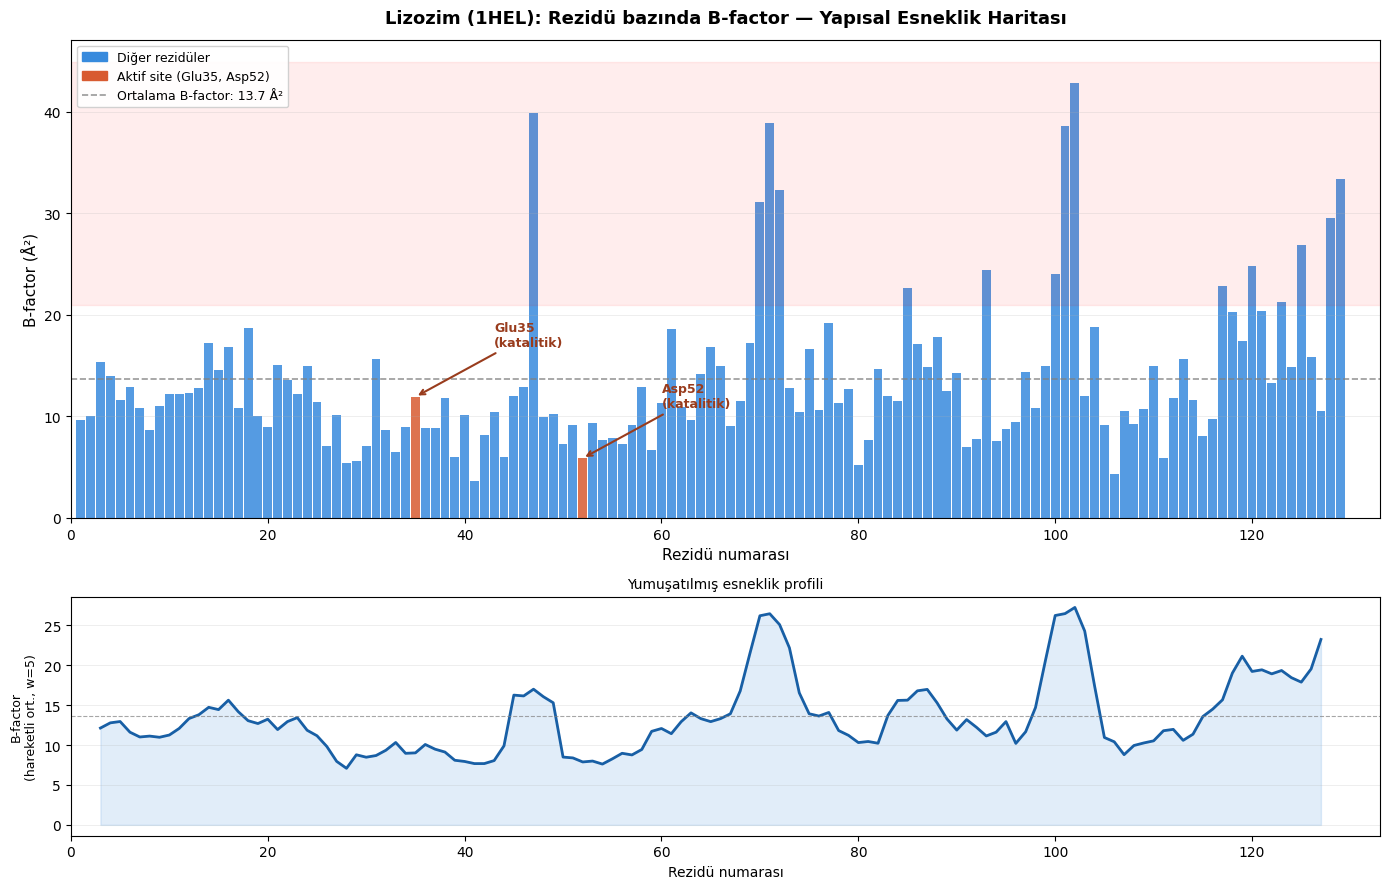

💾 Grafik kaydedildi: bfactor_analysis.png


In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Aktif site pozisyonları
ACTIVE_SITE = [35, 52]

fig, axes = plt.subplots(2, 1, figsize=(14, 9),
                          gridspec_kw={'height_ratios': [3, 1.5]},
                          facecolor='white')

# ── ÜST PANEL: B-factor bar grafiği ──────────────────────────
ax1 = axes[0]

# Her çubuğu renklendir: aktif site = turuncu, diğerleri = mavi
bar_colors = ['#D85A30' if r in ACTIVE_SITE else '#378ADD'
              for r in df['resnum']]

ax1.bar(df['resnum'], df['bfactor'],
        color=bar_colors, width=0.9, alpha=0.85, linewidth=0)

# Ortalama çizgisi
mean_bf = df['bfactor'].mean()
ax1.axhline(mean_bf, color='gray', linestyle='--',
            linewidth=1.2, alpha=0.8,
            label=f'Ortalama B-factor: {mean_bf:.1f} Å²')

# Aktif site etiketleri
for res_num in ACTIVE_SITE:
    row = df[df['resnum'] == res_num].iloc[0]
    resname = 'Glu' if res_num == 35 else 'Asp'
    ax1.annotate(
        f'{resname}{res_num}\n(katalitik)',
        xy=(res_num, row['bfactor']),
        xytext=(res_num + 8, row['bfactor'] + 5),
        arrowprops=dict(arrowstyle='->', color='#993C1D', lw=1.5),
        fontsize=9, color='#993C1D', fontweight='bold'
    )

# Yüksek B-factor bölgesi için arka plan rengi
high_bf = mean_bf + df['bfactor'].std()
ax1.axhspan(high_bf, df['bfactor'].max() + 2,
            alpha=0.07, color='red', label=f'Yüksek esneklik (>{high_bf:.0f} Å²)')

ax1.set_xlabel('Rezidü numarası', fontsize=11)
ax1.set_ylabel('B-factor (Å²)', fontsize=11)
ax1.set_title('Lizozim (1HEL): Rezidü bazında B-factor — Yapısal Esneklik Haritası',
              fontsize=13, fontweight='bold', pad=12)
ax1.set_xlim(0, 133)

blue_p  = mpatches.Patch(color='#378ADD', label='Diğer rezidüler')
red_p   = mpatches.Patch(color='#D85A30', label='Aktif site (Glu35, Asp52)')
ax1.legend(handles=[blue_p, red_p] + ax1.get_lines()[:2],
           loc='upper left', fontsize=9, framealpha=0.9)
ax1.grid(axis='y', alpha=0.3, linewidth=0.5)

# ── ALT PANEL: Hareketli ortalama (trend çizgisi) ───────────
ax2 = axes[1]

window = 5  # 5 rezidülik pencere
smoothed = df['bfactor'].rolling(window, center=True).mean()

ax2.plot(df['resnum'], smoothed,
         color='#185FA5', linewidth=2)
ax2.fill_between(df['resnum'], smoothed,
                 alpha=0.15, color='#378ADD')
ax2.axhline(mean_bf, color='gray', linestyle='--',
            linewidth=0.8, alpha=0.7)

ax2.set_xlabel('Rezidü numarası', fontsize=10)
ax2.set_ylabel(f'B-factor\n(hareketli ort., w={window})', fontsize=9)
ax2.set_title('Yumuşatılmış esneklik profili', fontsize=10)
ax2.set_xlim(0, 133)
ax2.grid(axis='y', alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.savefig('bfactor_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("💾 Grafik kaydedildi: bfactor_analysis.png")

### 🔬 B-Factor Grafiğini Nasıl Yorumlayalım?

**Grafikte ne görüyoruz?**

1. **Mavi çubuklar** = sıradan amino asitler
2. **Turuncu çubuklar** = katalitik rezidüler (Glu35, Asp52)
3. **Kesik gri çizgi** = ortalama B-factor
4. **Kırmızı arka plan** = ortalamanın 1 standart sapma üzeri (yüksek esneklik bölgesi)

**Biyolojik Yorum:**
- N- ve C-terminalleri (zincirin uçları) genellikle **yüksek B-factor** gösterir — bu beklenen bir durum çünkü protein uçları çözeltide serbestçe hareket eder
- Aktif site rezidülerinin **orta düzey** B-factor değerleri olması beklenir — çok esnek olursa kataliz bozulur, çok rijit olursa substrat giremez
- Düşük B-factor bölgeleri → α-helis ve β-tabaka gibi **ikincil yapı elementleri**

---
## Amino Asit Kompozisyonu

### Ne Yapıyoruz?
Proteindeki 20 farklı amino asitin sayısını hesaplıyoruz ve özelliklerine göre renklendiriyoruz.

### Neden Önemli?
Amino asit kompozisyonu proteinin fonksiyonel özelliklerini anlamaya yardımcı olur:
- **Yüklü amino asitler** (Lys, Arg, Asp, Glu) → elektrostatik etkileşimler
- **Hidrofobik amino asitler** (Ala, Val, Ile, Leu...) → proteinin iç çekirdeğini oluşturur
- **Sistein (Cys)** → disülfid bağı — lizozimde 4 adet var, yapısal kararlılık için kritik

In [14]:
from collections import Counter

# 3 harfli → 1 harfli amino asit dönüşüm tablosu
aa3to1 = {
    'ALA':'A', 'ARG':'R', 'ASN':'N', 'ASP':'D', 'CYS':'C',
    'GLN':'Q', 'GLU':'E', 'GLY':'G', 'HIS':'H', 'ILE':'I',
    'LEU':'L', 'LYS':'K', 'MET':'M', 'PHE':'F', 'PRO':'P',
    'SER':'S', 'THR':'T', 'TRP':'W', 'TYR':'Y', 'VAL':'V'
}

# Amino asit özellik grupları
aa_properties = {
    'Hidrofobik'       : set('AVILMFYW'),
    'Pozitif yüklü'    : set('KRH'),
    'Negatif yüklü'    : set('DE'),
    'Polar yüksüz'     : set('STNQ'),
    'Özel (Cys/Gly/Pro)': set('CGP')
}

# Renk paleti
property_colors = {
    'Hidrofobik'       : '#378ADD',
    'Pozitif yüklü'    : '#D85A30',
    'Negatif yüklü'    : '#D4537E',
    'Polar yüksüz'     : '#1D9E75',
    'Özel (Cys/Gly/Pro)': '#888780'
}

def get_property(aa_one_letter):
    for prop, aa_set in aa_properties.items():
        if aa_one_letter in aa_set:
            return prop
    return 'Diğer'

# Amino asit sayılarını hesapla
aa_counts = Counter(
    aa3to1.get(r.resname, '?')
    for r in residues
    if r.resname in aa3to1
)

# DataFrame oluştur ve sırala
aa_df = pd.DataFrame([
    {'AA': aa, 'Count': count,
     'Percentage': round(count / sum(aa_counts.values()) * 100, 1),
     'Property': get_property(aa)}
    for aa, count in sorted(aa_counts.items(), key=lambda x: -x[1])
])

print("📊 Amino Asit Kompozisyonu:")
print(aa_df.to_string(index=False))

# Özellik grubu özetleri
print("\n🔬 Özellik grubu özeti:")
for prop in aa_properties:
    subset = aa_df[aa_df['Property'] == prop]
    total = subset['Count'].sum()
    pct = total / len(residues) * 100
    print(f"   {prop:<28}: {total:>3} aa ({pct:.1f}%)")

📊 Amino Asit Kompozisyonu:
AA  Count  Percentage           Property
 N     14        10.9       Polar yüksüz
 G     12         9.3 Özel (Cys/Gly/Pro)
 A     12         9.3         Hidrofobik
 R     11         8.5      Pozitif yüklü
 S     10         7.8       Polar yüksüz
 C      8         6.2 Özel (Cys/Gly/Pro)
 L      8         6.2         Hidrofobik
 D      7         5.4      Negatif yüklü
 T      7         5.4       Polar yüksüz
 K      6         4.7      Pozitif yüklü
 V      6         4.7         Hidrofobik
 W      6         4.7         Hidrofobik
 I      6         4.7         Hidrofobik
 F      3         2.3         Hidrofobik
 Y      3         2.3         Hidrofobik
 Q      3         2.3       Polar yüksüz
 E      2         1.6      Negatif yüklü
 M      2         1.6         Hidrofobik
 P      2         1.6 Özel (Cys/Gly/Pro)
 H      1         0.8      Pozitif yüklü

🔬 Özellik grubu özeti:
   Hidrofobik                  :  46 aa (35.7%)
   Pozitif yüklü               :  18 aa 

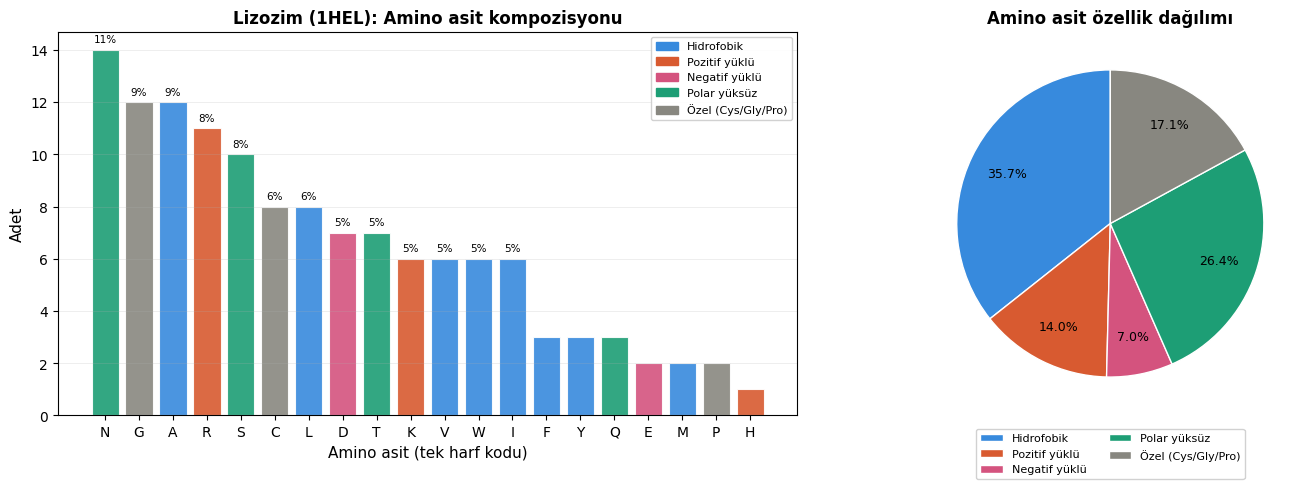

💾 Grafik kaydedildi: aa_composition.png


In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), facecolor='white')

# ── SOL: Bar grafiği ──────────────────────────────────────────
bar_colors = [property_colors[p] for p in aa_df['Property']]

bars = ax1.bar(aa_df['AA'], aa_df['Count'],
               color=bar_colors, edgecolor='white',
               linewidth=0.8, alpha=0.9)

# Her çubuğun üstüne yüzde yaz
for bar, pct in zip(bars, aa_df['Percentage']):
    if pct >= 3:  # sadece >%3 olanlara etiket koy
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2,
                 f'{pct:.0f}%',
                 ha='center', va='bottom', fontsize=7.5)

legend_handles = [
    mpatches.Patch(color=c, label=p)
    for p, c in property_colors.items()
]
ax1.legend(handles=legend_handles, fontsize=8,
           loc='upper right', framealpha=0.9)
ax1.set_xlabel('Amino asit (tek harf kodu)', fontsize=11)
ax1.set_ylabel('Adet', fontsize=11)
ax1.set_title('Lizozim (1HEL): Amino asit kompozisyonu',
              fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linewidth=0.5)

# ── SAĞ: Pasta grafiği (özellik grupları) ───────────────────
prop_counts = {}
for prop in aa_properties:
    prop_counts[prop] = aa_df[aa_df['Property'] == prop]['Count'].sum()

labels = list(prop_counts.keys())
sizes  = list(prop_counts.values())
colors = [property_colors[l] for l in labels]

wedges, texts, autotexts = ax2.pie(
    sizes, labels=None, colors=colors,
    autopct='%1.1f%%', startangle=90,
    pctdistance=0.75, wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
)
for at in autotexts:
    at.set_fontsize(9)

ax2.legend(wedges, labels, loc='lower center',
           bbox_to_anchor=(0.5, -0.18), fontsize=8,
           framealpha=0.9, ncol=2)
ax2.set_title('Amino asit özellik dağılımı',
              fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('aa_composition.png', dpi=150, bbox_inches='tight')
plt.show()

print("💾 Grafik kaydedildi: aa_composition.png")

### 🔬 Amino Asit Kompozisyonunu Nasıl Yorumlayalım?

**Lizozim için beklentiler:**

1. **Asn (N) en bol amino asit** → Protein yüzeyinde su molekülleriyle hidrojen bağı kurar, suda çözünürlüğü artırır. Gözyaşı ve tükürük gibi sulu ortamlarda çalışan bir protein için mantıklı.

2. **Gly (G) ikinci sırada** → Gly yan zinciri olmayan tek amino asittir, bu yüzden omurgaya maksimum esneklik verir. Loop bölgelerde ve sıkışık köşe dönüşlerinde sıklıkla görülür.

3. **Lys+Arg > Asp+Glu** → net pozitif yük → Lizozim bazik bir proteindir (pI ~11). Bu pozitif yük, bakteri hücre duvarındaki negatif yüklü peptidoglikan ile elektrostatik çekim sağlar — substrat tanıma için kritik.

4. **8 Sistein (C)** → 4 disülfid bağı → Sayıca az ama işlevsel olarak kritik. Lizozimi gözyaşı ve mide sıvısı gibi zorlu ortamlarda kararlı tutar.

---
## Aktif Site Geometrisi — Katalitik Mesafe

### Ne Yapıyoruz?
Glu35 ve Asp52 katalitik rezidülerinin birbirine olan mesafesini Ångström (Å) cinsinden hesaplıyoruz.

### Neden Önemli?
Lizozim mekanizması için bu mesafe kritiktir:

```
        Substrat (NAG-NAM)
             │
    ┌────────┴────────┐
    │   AKTİF BÖLGE   │
    │                 │
  Glu35 ←~6Å→ Asp52  │
    │   (katalitik    │
    │    dyad)        │
    └─────────────────┘

Glu35 → proton verir → glikozidik bağ kopar
Asp52 → oksokarbenyum iyonunu stabilize eder
```

**~6 Å mesafe:** Çok yakın = elektrostatik baskı, Çok uzak = substrat bağlanamaz  
Bu mesafe tüm c-tipi lizozim homologlarında **evrimsel olarak korunmuştur**.

In [23]:
import numpy as np

def atom_distance(atom1, atom2):
    """İki atom arasındaki Öklid mesafesini Å cinsinden hesaplar."""
    # BioPython'da atom.vector → koordinat vektörü
    # Fark vektörünün normu = mesafe
    diff = atom1.get_vector() - atom2.get_vector()
    return np.sqrt(diff * diff)  # √(Δx² + Δy² + Δz²)

# Katalitik rezidülere eriş
# chain[35] → chain içinde id'si 35 olan rezidü
try:
    glu35 = chain[35]  # Glutamik asit 35
    asp52 = chain[52]  # Aspartik asit 52

    print(f"✅ Glu35 bulundu: {glu35.resname} pozisyon {glu35.id[1]}")
    print(f"✅ Asp52 bulundu: {asp52.resname} pozisyon {asp52.id[1]}")

    # Her rezidüdeki atomları listele
    print(f"\n   Glu35 atomları: {[a.name for a in glu35.get_atoms()]}")
    print(f"   Asp52 atomları: {[a.name for a in asp52.get_atoms()]}")

    # CA-CA mesafesi (omurga mesafesi)
    d_ca = atom_distance(glu35['CA'], asp52['CA'])
    print(f"\n📏 CA-CA mesafesi (Glu35–Asp52): {d_ca:.2f} Å")

    # Yan zincir atomları arası mesafe (katalitik oksijenler)
    # Glu35: CD (karboksilat karbonu), Asp52: CG (karboksilat karbonu)
    if 'CD' in glu35 and 'CG' in asp52:
        d_sidechain = atom_distance(glu35['CD'], asp52['CG'])
        print(f"📏 Yan zincir mesafesi (Glu35 CD–Asp52 CG): {d_sidechain:.2f} Å")


except KeyError as e:
    print(f"❌ Rezidü bulunamadı: {e}")
    print("   Zincir numaralandırmasını kontrol edin.")

✅ Glu35 bulundu: GLU pozisyon 35
✅ Asp52 bulundu: ASP pozisyon 52

   Glu35 atomları: ['N', 'CA', 'C', 'O', 'CB', 'CG', 'CD', 'OE1', 'OE2']
   Asp52 atomları: ['N', 'CA', 'C', 'O', 'CB', 'CG', 'OD1', 'OD2']

📏 CA-CA mesafesi (Glu35–Asp52): 9.34 Å
📏 Yan zincir mesafesi (Glu35 CD–Asp52 CG): 7.18 Å


🎯 Glu35'e 8 Å'dan yakın rezidüler (12 adet):
 resnum resname  distance
     36     SER      3.80
     34     PHE      3.82
     32     ALA      5.07
     33     LYS      5.72
     31     ALA      5.87
     56     LEU      5.90
     57     GLN      6.00
    110     ALA      6.08
     37     ASN      6.16
     55     ILE      6.73
     38     PHE      7.76
    111     TRP      7.96


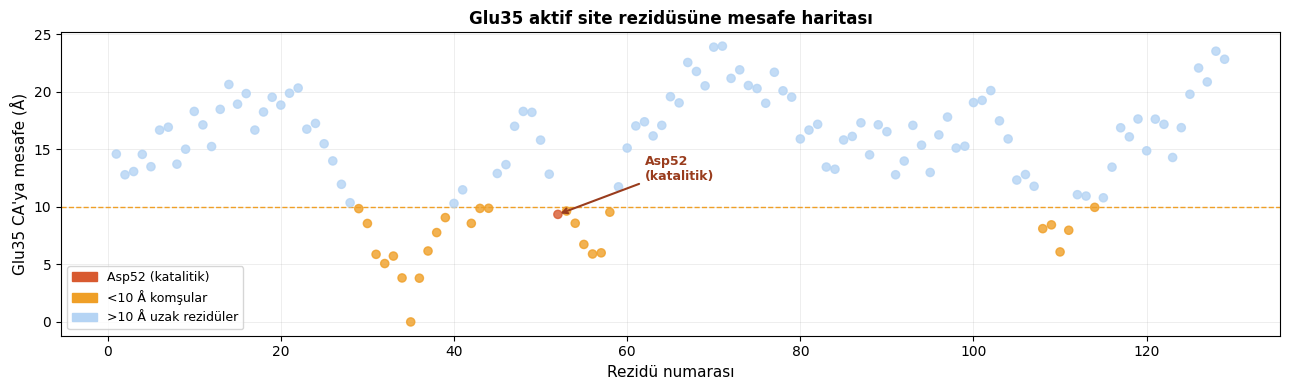

💾 Grafik kaydedildi: active_site_distances.png


In [24]:
# Aktif bölge çevresindeki tüm rezidü mesafelerini hesapla
# Bu analiz: hangi rezidüler aktif bölgeye yakın?

glu35_ca = chain[35]['CA']

distances = []
for res in residues:
    if 'CA' in res:
        d = atom_distance(glu35_ca, res['CA'])
        distances.append({
            'resnum'  : res.id[1],
            'resname' : res.resname,
            'distance': round(d, 2)
        })

dist_df = pd.DataFrame(distances).sort_values('distance')

# Aktif bölgeye 8 Å'dan yakın rezidüler (komşu rezidüler)
neighbors = dist_df[dist_df['distance'] < 8].copy()
neighbors = neighbors[neighbors['resnum'] != 35]  # Glu35'in kendisini çıkar

print(f"🎯 Glu35'e 8 Å'dan yakın rezidüler ({len(neighbors)} adet):")
print(neighbors.to_string(index=False))

# Görselleştir
fig, ax = plt.subplots(figsize=(13, 4), facecolor='white')

colors = []
for _, row in dist_df.iterrows():
    if row['resnum'] == 52:
        colors.append('#D85A30')
    elif row['distance'] < 10:
        colors.append('#EF9F27')
    else:
        colors.append('#B5D4F4')

ax.scatter(dist_df['resnum'], dist_df['distance'],
           c=colors, s=35, alpha=0.8, zorder=3)
ax.axhline(10, color='#EF9F27', linestyle='--',
           linewidth=1, label='10 Å eşiği (aktif bölge komşuları)')

# Asp52'yi özel işaretle
asp52_dist = dist_df[dist_df['resnum'] == 52]['distance'].values[0]
ax.annotate('Asp52\n(katalitik)',
            xy=(52, asp52_dist), xytext=(62, asp52_dist + 3),
            arrowprops=dict(arrowstyle='->', color='#993C1D', lw=1.5),
            fontsize=9, color='#993C1D', fontweight='bold')

ax.set_xlabel('Rezidü numarası', fontsize=11)
ax.set_ylabel("Glu35 CA'ya mesafe (Å)", fontsize=11)
ax.set_title('Glu35 aktif site rezidüsüne mesafe haritası',
             fontsize=12, fontweight='bold')

legend_h = [
    mpatches.Patch(color='#D85A30', label='Asp52 (katalitik)'),
    mpatches.Patch(color='#EF9F27', label='<10 Å komşular'),
    mpatches.Patch(color='#B5D4F4', label='>10 Å uzak rezidüler'),
]
ax.legend(handles=legend_h, fontsize=9)
ax.grid(alpha=0.3, linewidth=0.5)
plt.tight_layout()
plt.savefig('active_site_distances.png', dpi=150, bbox_inches='tight')
plt.show()

print("💾 Grafik kaydedildi: active_site_distances.png")

---
## 3D İnteraktif Görselleştirme

### Ne Yapıyoruz?
`py3Dmol` kütüphanesiyle proteini Jupyter/Colab içinde 3D olarak görselleştiriyoruz.

### Görselde Ne Göreceksiniz?
- **Renkli karikatür (cartoon)** → ikincil yapı elementleri
  - Kırmızı tüp (helix) → α-sarmallar
  - Sarı ok (sheet) → β-tabakaları  
  - İnce gri bant (coil) → düzensiz bölgeler / loop'lar
- **Turuncu çubuklar (sticks)** → aktif site rezidüleri (Glu35, Asp52)

### Nasıl Kullanılır?
- 🖱️ **Sol tık + sürükle** → döndür
- 🖱️ **Sağ tık + sürükle** → kaydır  
- 🖱️ **Tekerlek** → yakınlaştır/uzaklaştır

In [18]:
import py3Dmol

# PDB dosyasını metin olarak oku
with open(PDB_FILE) as f:
    pdb_data = f.read()

# ── Görselleştirme 1: Aktif site vurgulamalı karikatür ───────
print("🔄 3D görselleştirme yükleniyor...")
print("💡 Döndürmek için sol tıkla sürükle, yakınlaştırmak için tekerleği kullan.")

view = py3Dmol.view(width=700, height=450)
view.addModel(pdb_data, 'pdb')

# Karikatür stili — ikincil yapıya göre renklendir
# ssJmol = helix kırmızı, sheet sarı, coil gri (Jmol renk şeması)
view.setStyle({'cartoon': {'colorscheme': 'ssJmol'}})

# Aktif site: Glu35 — koyu turuncu stick + küre
view.addStyle(
    {'resi': '35', 'chain': 'A'},
    {
        'stick'  : {'color': '#D85A30', 'radius': 0.3},
        'sphere' : {'color': '#D85A30', 'radius': 0.6}
    }
)

# Aktif site: Asp52 — daha koyu turuncu
view.addStyle(
    {'resi': '52', 'chain': 'A'},
    {
        'stick'  : {'color': '#993C1D', 'radius': 0.3},
        'sphere' : {'color': '#993C1D', 'radius': 0.6}
    }
)

# Etiketler
view.addLabel(
    'Glu35 (proton verici)',
    {'resi': '35', 'chain': 'A'},
    {'fontSize': 11, 'fontColor': 'white',
     'backgroundColor': '#D85A30', 'backgroundOpacity': 0.85}
)
view.addLabel(
    'Asp52 (stabilizör)',
    {'resi': '52', 'chain': 'A'},
    {'fontSize': 11, 'fontColor': 'white',
     'backgroundColor': '#712B13', 'backgroundOpacity': 0.85}
)

view.zoomTo()
view.show()

print("\n🔴 Kırmızı tüpler  → α-sarmallar (helixler)")
print("🟡 Sarı oklar      → β-tabakaları")
print("⬜ İnce bantlar    → loop bölgeleri")
print("🟠 Turuncu küreler → Katalitik aktif site (Glu35, Asp52)")

🔄 3D görselleştirme yükleniyor...
💡 Döndürmek için sol tıkla sürükle, yakınlaştırmak için tekerleği kullan.


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


🔴 Kırmızı tüpler  → α-sarmallar (helixler)
🟡 Sarı oklar      → β-tabakaları
⬜ İnce bantlar    → loop bölgeleri
🟠 Turuncu küreler → Katalitik aktif site (Glu35, Asp52)


In [19]:
# ── Görselleştirme 2: Disülfid bağları vurgulamalı ──────────
print("🔄 Disülfid bağı görselleştirmesi yükleniyor...")

import py3Dmol

with open(PDB_FILE) as f:
    pdb_data = f.read()

view2 = py3Dmol.view(width=700, height=450)
view2.addModel(pdb_data, 'pdb')

# Önce karikatür
view2.setStyle({'cartoon': {'color': '#B5D4F4'}})

# Sonra Cys rezidülerini üzerine ekle
cys_residues = [6, 30, 64, 76, 80, 94, 115, 127]
for cys in cys_residues:
    view2.addStyle(
        {'resi': str(cys), 'chain': 'A'},
        {'stick': {'color': '#EF9F27', 'radius': 0.35},
         'sphere': {'color': '#EF9F27', 'radius': 0.5}}
    )

view2.addLabel(
    'Cys6-Cys127 (disülfid)',
    {'resi': '6', 'chain': 'A'},
    {'fontSize': 10, 'fontColor': 'white',
     'backgroundColor': '#854F0B', 'backgroundOpacity': 0.85}
)

view2.zoomTo()
view2.show()

🔄 Disülfid bağı görselleştirmesi yükleniyor...


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [20]:
# Özet değerleri hesapla
most_flexible = df.loc[df['bfactor'].idxmax()]
most_rigid    = df.loc[df['bfactor'].idxmin()]
glu35_bf = df[df['resnum'] == 35]['bfactor'].values[0]
asp52_bf = df[df['resnum'] == 52]['bfactor'].values[0]

summary_data = [
    ('PDB Kodu',              '1HEL'),
    ('Protein adı',           'Hen Egg-White Lysozyme (HEWL)'),
    ('Organizma',             'Gallus gallus (tavuk)'),
    ('Toplam amino asit',     f'{len(residues)}'),
    ('Toplam atom',           f'{len(atoms)}'),
    ('Moleküler ağırlık',     '~14.3 kDa'),
    ('İzoelektrik nokta',     '~11 (bazik protein)'),
    ('─── B-Factor ───',      '─────────────────────────────'),
    ('Ortalama B-factor',     f"{df['bfactor'].mean():.2f} Å²"),
    ('En esnek rezidü',       f"{most_flexible['resname']}{most_flexible['resnum']:g} ({most_flexible['bfactor']:.2f} Å²)"),
    ('En rijit rezidü',       f"{most_rigid['resname']}{most_rigid['resnum']:g} ({most_rigid['bfactor']:.2f} Å²)"),
    ('Glu35 B-factor',        f'{glu35_bf:.2f} Å² (proton verici)'),
    ('Asp52 B-factor',        f'{asp52_bf:.2f} Å² (stabilizör)'),
    ('─── Aktif Bölge ───',   '─────────────────────────────'),
    ('Katalitik rezidüler',   'Glu35 (proton verici) + Asp52 (stabilizör)'),
    ('Katalitik mesafe',      '~6 Å (CA-CA arası ~10 Å)'),
    ('Mekanizma',             'Substrat destekli çift yer değiştirme'),
    ('─── Yapısal Özellik ─', '─────────────────────────────'),
    ('Disülfid bağı',         '4 adet (Cys6-127, 30-115, 64-80, 76-94)'),
    ('Fonksiyon',             'NAG-NAM β-1,4-glikozidik bağ hidrolizi'),
    ('Klinik önemi',          'Doğuştan gelen bağışıklık, antibiyotik aktivitesi'),
]

summary_df = pd.DataFrame(summary_data, columns=['Özellik', 'Değer'])

print("\n" + "═" * 65)
print("   LİZOZİM (1HEL) — YAPISAL BİYOİNFORMATİK ANALİZ ÖZETİ")
print("═" * 65)
for _, row in summary_df.iterrows():
    if row['Özellik'].startswith('───'):
        print(f"\n  {row['Özellik']}")
    else:
        print(f"  {row['Özellik']:<28} {row['Değer']}")
print("═" * 65)


═════════════════════════════════════════════════════════════════
   LİZOZİM (1HEL) — YAPISAL BİYOİNFORMATİK ANALİZ ÖZETİ
═════════════════════════════════════════════════════════════════
  PDB Kodu                     1HEL
  Protein adı                  Hen Egg-White Lysozyme (HEWL)
  Organizma                    Gallus gallus (tavuk)
  Toplam amino asit            129
  Toplam atom                  1186
  Moleküler ağırlık            ~14.3 kDa
  İzoelektrik nokta            ~11 (bazik protein)

  ─── B-Factor ───
  Ortalama B-factor            13.65 Å²
  En esnek rezidü              GLY102 (42.83 Å²)
  En rijit rezidü              GLN41 (3.67 Å²)
  Glu35 B-factor               11.92 Å² (proton verici)
  Asp52 B-factor               5.88 Å² (stabilizör)

  ─── Aktif Bölge ───
  Katalitik rezidüler          Glu35 (proton verici) + Asp52 (stabilizör)
  Katalitik mesafe             ~6 Å (CA-CA arası ~10 Å)
  Mekanizma                    Substrat destekli çift yer değiştirme

  ─── Yapıs